In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygments.lexers import factor

In [91]:
# ── Change this one variable to switch between algorithms ──────────────────
# Options: "lasso", "xgboost", "xgboost_expanding",
#          "xgboost_factor_screened", "benchmark", "factor"
ALGO = "xgboost_factor_screened"

BACKTEST_DIR = f"../data/backtest/{ALGO}"

In [92]:
data = pd.read_parquet('../data/processed/data.parquet')

In [93]:
data = data.sort_values(by=['eom', 'id'], ascending = True)

In [94]:
data['ret'].min()

np.float64(-0.999993846)

In [95]:
for col in data.columns.to_list():
    print(col)

id
date
eom
source_crsp
size_grp
obs_main
exch_main
primary_sec
gvkey
iid
permno
permco
excntry
curcd
fx
common
comp_tpci
crsp_shrcd
comp_exchg
crsp_exchcd
adjfct
shares
me_lag1
gics
sic
naics
ff49
me_company
prc
prc_local
dolvol
ret
ret_lag_dif
ret_exc_lead1m
enterprise_value
book_equity
assets
sales
net_income
bidask
prc_high
prc_low
tvol
div1m_me
div3m_me
div6m_me
div12m_me
divspc1m_me
divspc12m_me
chcsho_1m
chcsho_3m
chcsho_6m
chcsho_12m
eqnpo_1m
eqnpo_3m
eqnpo_6m
eqnpo_12m
ret_1_0
ret_2_0
ret_3_0
ret_3_1
ret_6_0
ret_6_1
ret_9_0
ret_9_1
ret_12_0
ret_12_1
ret_12_7
ret_18_1
ret_24_1
ret_24_12
ret_36_1
ret_36_12
ret_48_12
ret_48_1
ret_60_1
ret_60_12
ret_60_36
seas_1_1an
seas_1_1na
seas_2_5an
seas_2_5na
seas_6_10an
seas_6_10na
seas_11_15an
seas_11_15na
seas_16_20an
seas_16_20na
at_gr1
ca_gr1
nca_gr1
lt_gr1
cl_gr1
ncl_gr1
be_gr1
pstk_gr1
debt_gr1
sale_gr1
cogs_gr1
sga_gr1
opex_gr1
capx_gr1
inv_gr1
at_gr3
ca_gr3
nca_gr3
lt_gr3
cl_gr3
ncl_gr3
be_gr3
pstk_gr3
debt_gr3
sale_gr3
cogs_gr3
sga

In [96]:
len(data.columns)

438

In [97]:
port = pd.read_csv(f'{BACKTEST_DIR}/portfolios.csv')
port

,id,leg,weight,predicted_ret,realized_ret,eom
0,100845801,long,0.006516,0.012653,0.174937,1986-01-31
1,100197601,long,0.015635,0.012653,-0.055716,1986-01-31
2,100532101,long,0.015727,0.012656,0.139679,1986-01-31
3,100141001,long,0.001222,0.012668,-0.016595,1986-01-31
4,100159301,long,0.001696,0.012679,0.177244,1986-01-31
...,...,...,...,...,...,...
223735,114834901,short,-0.015875,0.004700,0.036480,2025-10-31
223736,101356101,short,-0.000262,0.004718,0.102417,2025-10-31
223737,103195801,short,-0.000786,0.004722,-0.041808,2025-10-31
223738,116392001,short,-0.006481,0.004754,0.056703,2025-10-31


In [98]:
algo_ret = pd.read_csv(f'{BACKTEST_DIR}/monthly_returns.csv')
algo_ret

,eom,ic_pearson,ic_spearman,best_iteration,n_train,n_features,scoring_year,train_end_year,long_ret,short_ret,qspread,net_qspread,turnover,n_long,n_short,n_universe
0,1986-01-31,0.068655,0.093445,5,149779,83,1986,1985,0.077550,0.055871,0.021680,0.019680,1.000000,169,169,1692
1,1986-02-28,0.118319,0.127209,5,149779,83,1986,1985,0.066211,0.031599,0.034613,0.033105,0.753857,169,169,1698
2,1986-03-31,-0.049098,-0.036999,5,149779,83,1986,1985,-0.020663,0.021628,-0.042292,-0.043861,0.784676,174,174,1745
3,1986-04-30,0.053778,0.066218,5,149779,83,1986,1985,0.068578,0.053765,0.014812,0.013236,0.788013,175,175,1756
4,1986-05-31,0.049410,0.038510,5,149779,83,1986,1985,0.016550,-0.013258,0.029809,0.028526,0.641421,176,176,1765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,2025-06-30,-0.000391,0.028393,43,1751432,27,2025,2024,0.022633,0.010065,0.012568,0.012085,0.241185,178,178,1785
474,2025-07-31,0.108290,0.165067,43,1751432,27,2025,2024,0.077260,0.020728,0.056532,0.055044,0.744193,178,178,1780
475,2025-08-31,-0.009569,-0.067690,43,1751432,27,2025,2024,0.001471,0.009504,-0.008033,-0.008653,0.309835,179,179,1796
476,2025-09-30,-0.043469,-0.046566,43,1751432,27,2025,2024,-0.014128,-0.032927,0.018799,0.018117,0.340846,180,180,1807


In [99]:
idx = np.where(algo_ret['net_qspread'] == algo_ret['net_qspread'].max())
idx

(array([169]),)

<Axes: >

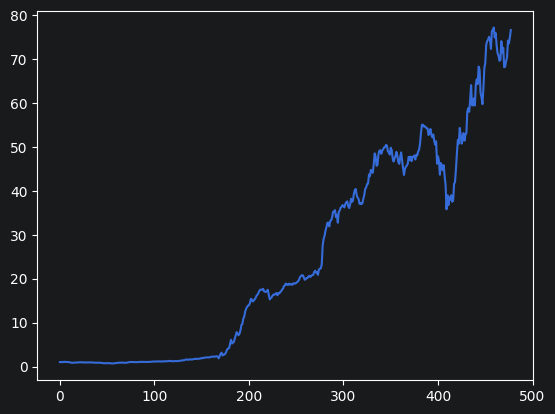

In [100]:
(1 + algo_ret['net_qspread']).cumprod().plot()

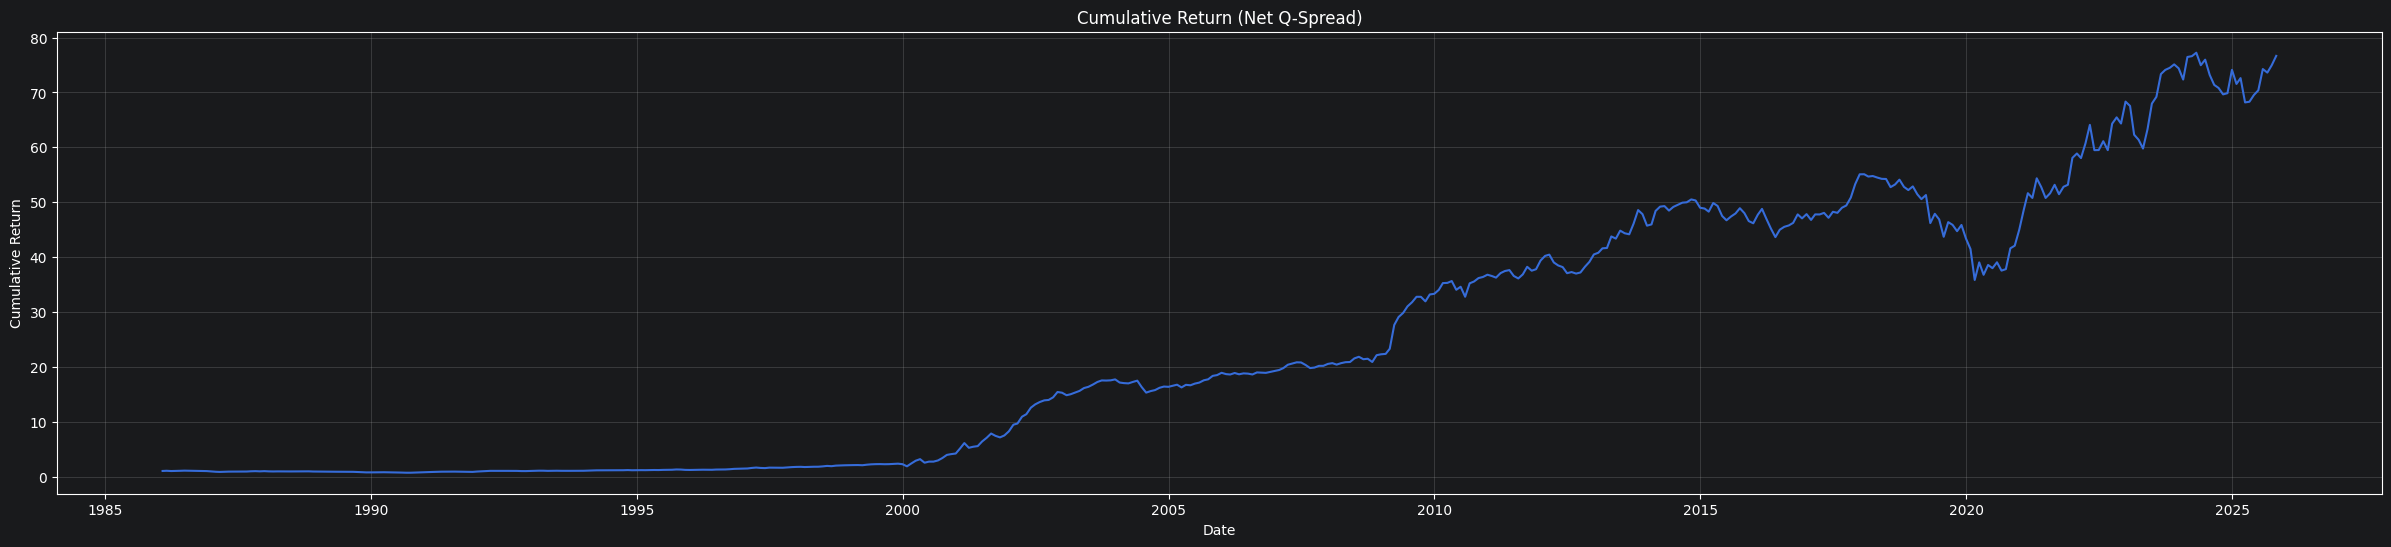

In [101]:
# Ensure datetime
algo_ret['eom'] = pd.to_datetime(algo_ret['eom'])

# Sort by date
xg_boost_ret = algo_ret.sort_values('eom')

# Cumulative return
series = (1 + algo_ret['net_qspread']).cumprod()

# Plot (wider figure)
plt.figure(figsize=(30, 6))
plt.plot(algo_ret['eom'], series)

plt.title('Cumulative Return (Net Q-Spread)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=0.3)

plt.show()

In [102]:
factor_df = pd.read_csv(f'{BACKTEST_DIR}/feature_importance.csv', on_bad_lines="skip")
factor_df

,Unnamed: 0,bidask,eqnpo_3m,ret_3_1,ret_6_1,ret_12_1,ret_12_7,seas_1_1an,nfna_gr1a,ocf_gr1a,...,ebit_mev,cop_mev,ocf_mev,fcf_mev,debt_mev,debtlt_mev,debtst_mev,mispricing_mgmt,mispricing_perf,qmj_prof
0,1986-01-31,0.019739,0.042267,0.014235,0.024022,0.055034,0.041948,0.037864,0.013162,0.007541,...,0.013919,0.016648,0.033821,0.0,0.009414,0.00827,0.00383,0.010023,0.013134,0.016092
1,1986-02-28,0.019739,0.042267,0.014235,0.024022,0.055034,0.041948,0.037864,0.013162,0.007541,...,0.013919,0.016648,0.033821,0.0,0.009414,0.00827,0.00383,0.010023,0.013134,0.016092
2,1986-03-31,0.019739,0.042267,0.014235,0.024022,0.055034,0.041948,0.037864,0.013162,0.007541,...,0.013919,0.016648,0.033821,0.0,0.009414,0.00827,0.00383,0.010023,0.013134,0.016092
3,1986-04-30,0.019739,0.042267,0.014235,0.024022,0.055034,0.041948,0.037864,0.013162,0.007541,...,0.013919,0.016648,0.033821,0.0,0.009414,0.00827,0.00383,0.010023,0.013134,0.016092
4,1986-05-31,0.019739,0.042267,0.014235,0.024022,0.055034,0.041948,0.037864,0.013162,0.007541,...,0.013919,0.016648,0.033821,0.0,0.009414,0.00827,0.00383,0.010023,0.013134,0.016092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,2025-06-30,0.024583,0.023567,0.021048,0.031272,0.024183,0.025535,0.026444,0.025940,0.023004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
450,2025-07-31,0.024583,0.023567,0.021048,0.031272,0.024183,0.025535,0.026444,0.025940,0.023004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
451,2025-08-31,0.024583,0.023567,0.021048,0.031272,0.024183,0.025535,0.026444,0.025940,0.023004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
452,2025-09-30,0.024583,0.023567,0.021048,0.031272,0.024183,0.025535,0.026444,0.025940,0.023004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [103]:
for factor in factor_df:
    print(factor)

Unnamed: 0
bidask
eqnpo_3m
ret_3_1
ret_6_1
ret_12_1
ret_12_7
seas_1_1an
nfna_gr1a
ocf_gr1a
fcf_gr1a
xido_at
nri_at
ocf_sale
fcf_sale
gp_at
cop_at
ope_be
ni_be
nix_be
ocf_be
fcf_be
gp_bev
ebitda_bev
ebit_bev
cop_bev
gp_ppen
ebitda_ppen
fcf_ppen
eqnpo_at
eqbb_at
ocf_cl
ocf_debt
lt_ppen
opex_at
inv_turnover
at_turnover
rec_turnover
ap_turnover
sale_bev
sale_be
sale_nwc
tax_pi
niq_be
niq_at
cop_atl1
pi_nix
ocf_at
ocf_at_chg1
at_be
at_me
be_me
debt_me
cash_me
sale_me
gp_me
ebitda_me
ebit_me
ope_me
ni_me
nix_me
cop_me
ocf_me
fcf_me
eqbb_me
eqnpo_me
ival_me
at_mev
bev_mev
be_mev
cash_mev
sale_mev
gp_mev
ebitda_mev
ebit_mev
cop_mev
ocf_mev
fcf_mev
debt_mev
debtlt_mev
debtst_mev
mispricing_mgmt
mispricing_perf
qmj_prof
